#Integrantes:

Ivan Moreno Galindo  
Dayron Silva Velázquez  
Armando Barrios

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
import time
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from google.colab import drive
from xgboost import XGBRegressor

drive.mount('/content/drive')

# https://drive.google.com/file/d/18bQpWhnMC4E5RoJ5n1Lheax3DMMcLv38/view?usp=sharing
flie_id = "18bQpWhnMC4E5RoJ5n1Lheax3DMMcLv38"

url = f"https://drive.google.com/uc?id={flie_id}"
df = pd.read_csv(url)

diabetes = pd.read_csv(url)

diabetes.head()

Mounted at /content/drive


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
diabetes[["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age","Outcome"]] =diabetes[["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age","Outcome"]].astype("int")

In [ ]:
diabetes.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,int64
DiabetesPedigreeFunction,int64
Age,int64
Outcome,int64


In [ ]:
X = df[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','Outcome','DiabetesPedigreeFunction','Age']]
y = df['BMI']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Punto Numero 1: Regresion Lineal Multiple**

In [ ]:
# 1
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
#1
y_pred = model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error cuadrático medio (MSE): {mse_rf:.2f}")
print(f"Coeficiente de determinación (R²): {r2:.2f}")

Error cuadrático medio (MSE): 52.46
Coeficiente de determinación (R²): 0.26


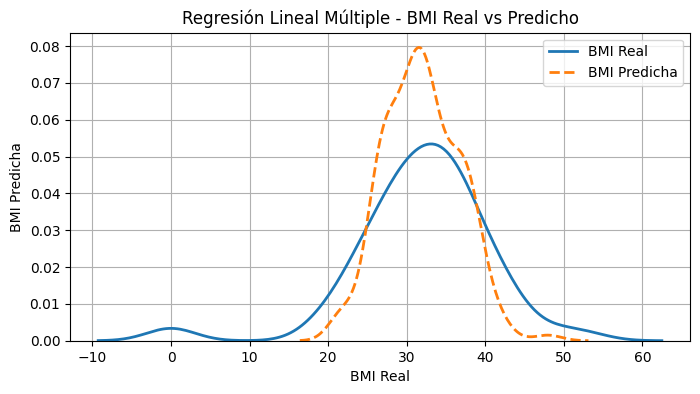

In [ ]:
#1
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='BMI Real', linewidth=2)
sns.kdeplot(y_pred, label='BMI Predicha', linewidth=2, linestyle='--')
plt.xlabel("BMI Real")
plt.ylabel("BMI Predicha")
plt.title("Regresión Lineal Múltiple - BMI Real vs Predicho")
plt.grid(True)
plt.legend()
plt.show()

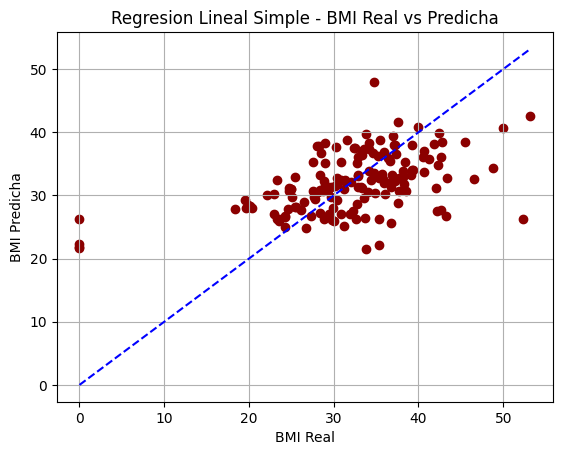

In [ ]:
#1
plt.scatter(y_test, y_pred, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--')
plt.xlabel("BMI Real")
plt.ylabel("BMI Predicha")
plt.title("Regresion Lineal Simple - BMI Real vs Predicha")
plt.grid(True)
plt.show()

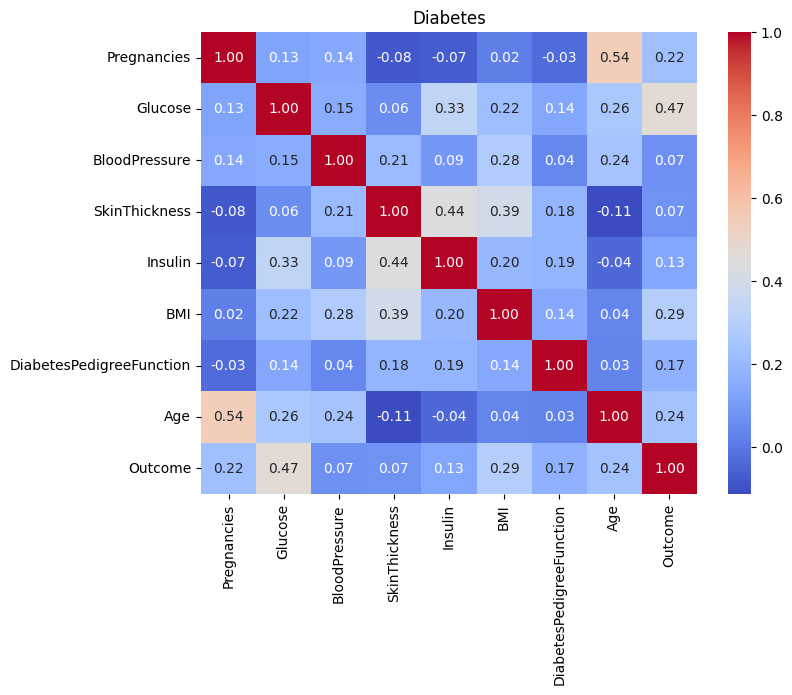

In [ ]:
#1
corr_lineal = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_lineal, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Diabetes')
plt.show()

# Punto 2 Árbol de Decisión para Regresión.

In [ ]:
# 2
tree_model = DecisionTreeRegressor(random_state=42, max_depth=4)
tree_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=42)

In [ ]:
#2
y_pred_tree = tree_model.predict(X_test)
mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print(f"Error cuadrático medio (MSE): {mse_tree:.2f}")
print(f"Coeficiente de determinación (R²): {r2_tree:.2f}")

Error cuadrático medio (MSE): 63.24
Coeficiente de determinación (R²): 0.11


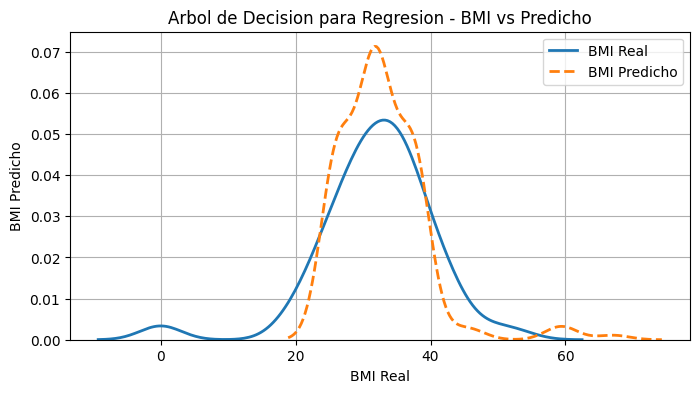

In [ ]:
#2
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='BMI Real', linewidth=2)
sns.kdeplot(y_pred_tree, label='BMI Predicho', linewidth=2, linestyle='--')
plt.xlabel("BMI Real")
plt.ylabel("BMI Predicho")
plt.title("Arbol de Decision para Regresion - BMI vs Predicho")
plt.grid(True)
plt.legend()
plt.show()

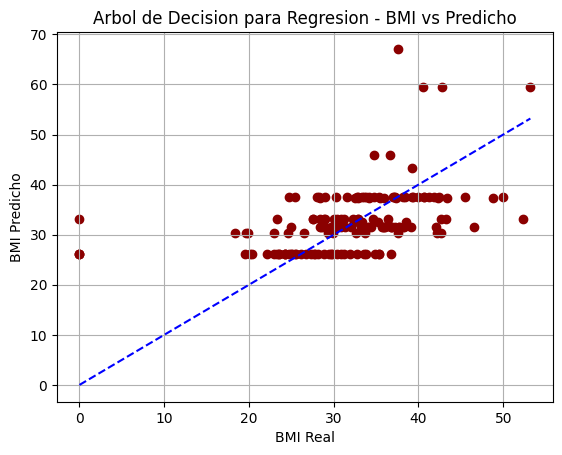

In [ ]:
#2
plt.scatter(y_test, y_pred_tree, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--')  # Linea ideala
plt.xlabel("BMI Real")
plt.ylabel("BMI Predicho")
plt.title("Arbol de Decision para Regresion - BMI vs Predicho")
plt.grid(True)
plt.show()

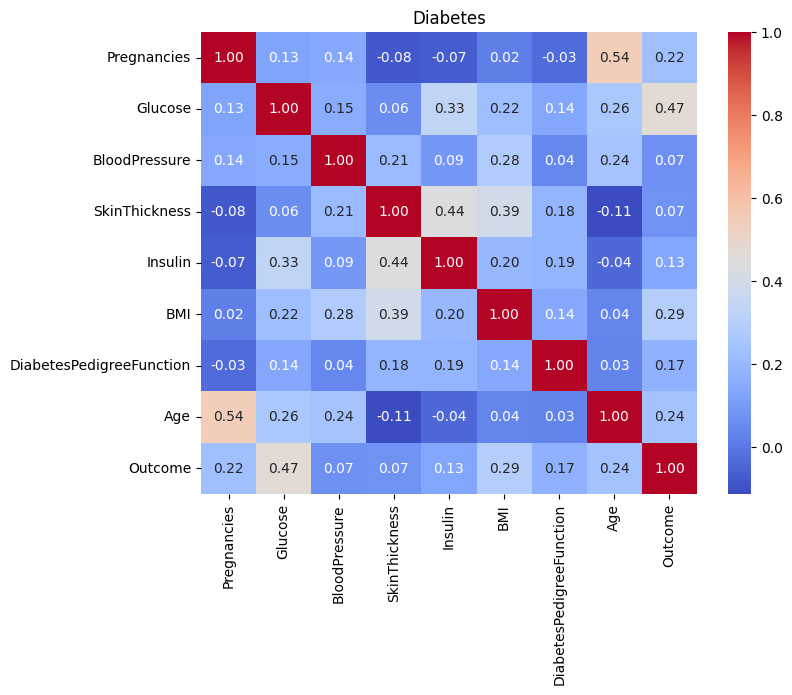

In [ ]:
#2
corr_arbol = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_arbol, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Diabetes')
plt.show()

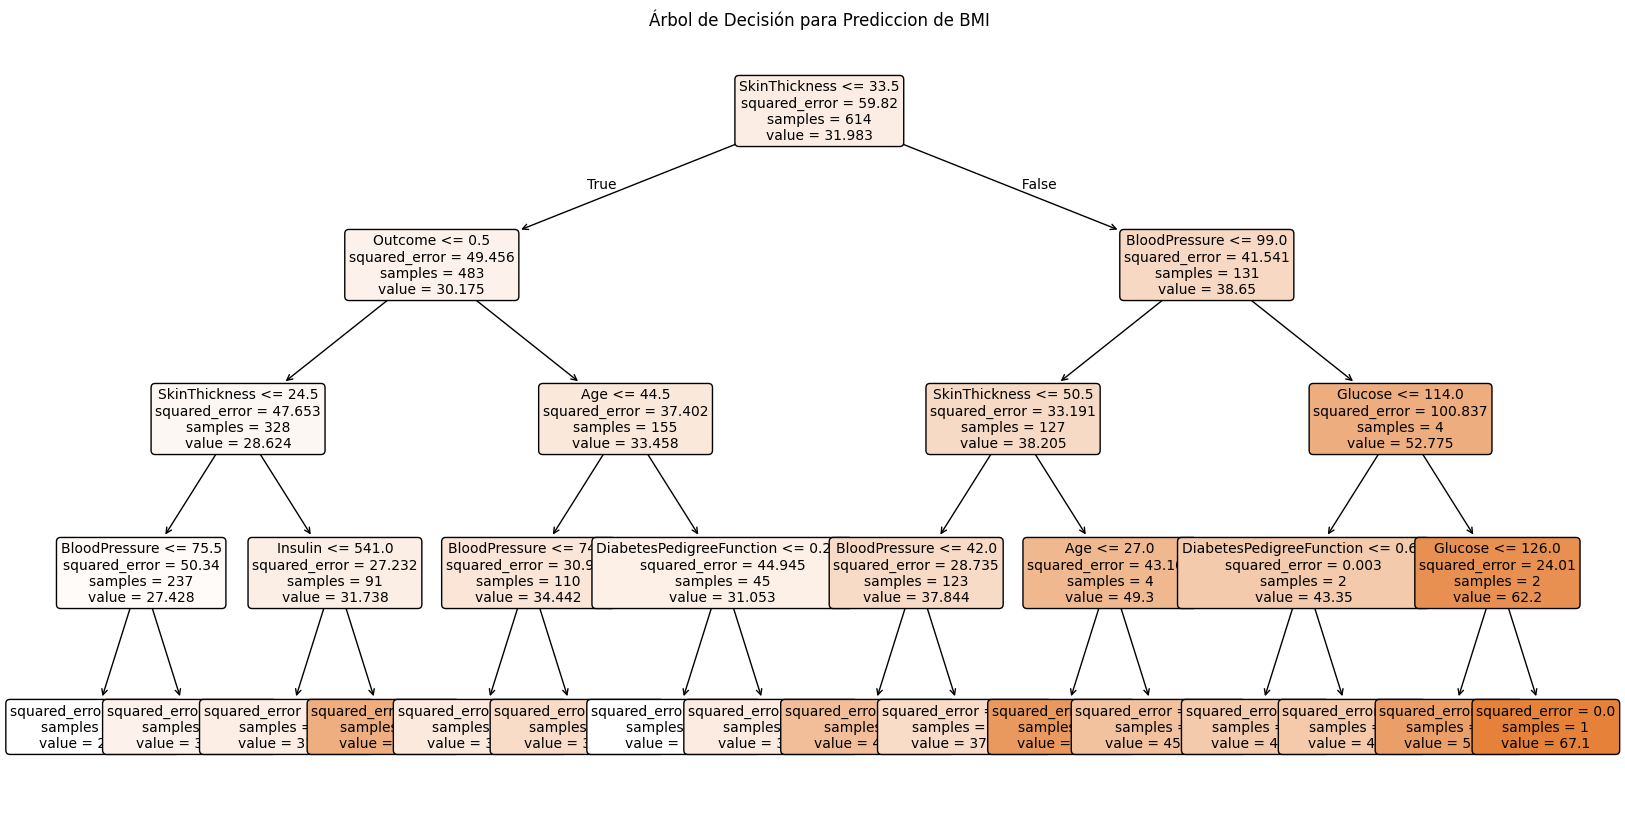

In [ ]:
#2
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(tree_model, feature_names=X.columns, filled=True, rounded=True, fontsize=10)
plt.title("Árbol de Decisión para Prediccion de BMI")
plt.show()

# Punto 3 Random Forest Regressor

In [ ]:
#3
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
#3
import numpy as np
rmse = np.sqrt(mse_rf)
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")

Raíz del Error cuadrático medio (RMSE): 7.24


In [ ]:
#3
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Error cuadrático medio (MSE): {mse_rf:.2f}")
print(f"Coeficiente de determinación (R²): {r2_rf:.2f}")

Error cuadrático medio (MSE): 50.02
Coeficiente de determinación (R²): 0.30


In [ ]:
#3
rf_model = RandomForestRegressor(
n_estimators=200, # más árboles
max_depth=8, # limitar profundidad
min_samples_split=4, # evitar divisiones con pocos datos
min_samples_leaf=3, # cada hoja al menos con 3 observaciones
max_features='sqrt', # usa raíz cuadrada del total de features
random_state=42
)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")
print(f"RMSE: {np.sqrt(mse):.2f}")

MSE: 46.02
R²: 0.35
RMSE: 6.78


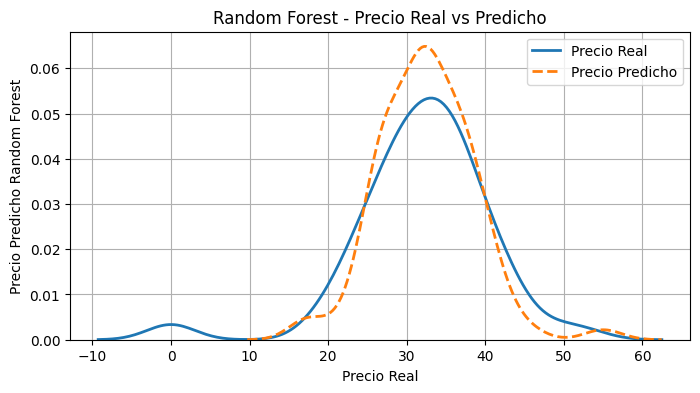

In [ ]:
#3
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred_rf, label='Precio Predicho', linewidth=2, linestyle='--')
plt.title('Random Forest - Precio Real vs Predicho')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho Random Forest')
plt.legend()
plt.grid(True)
plt.show()

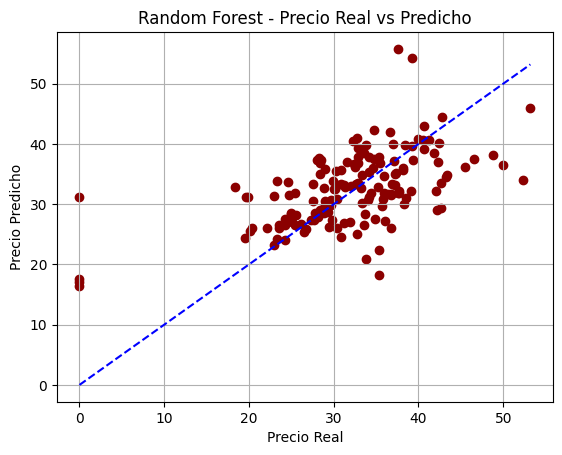

In [ ]:
#3
plt.scatter(y_test, y_pred_rf, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') # Línea ideal
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Random Forest - Precio Real vs Predicho")
plt.grid(True)
plt.show()

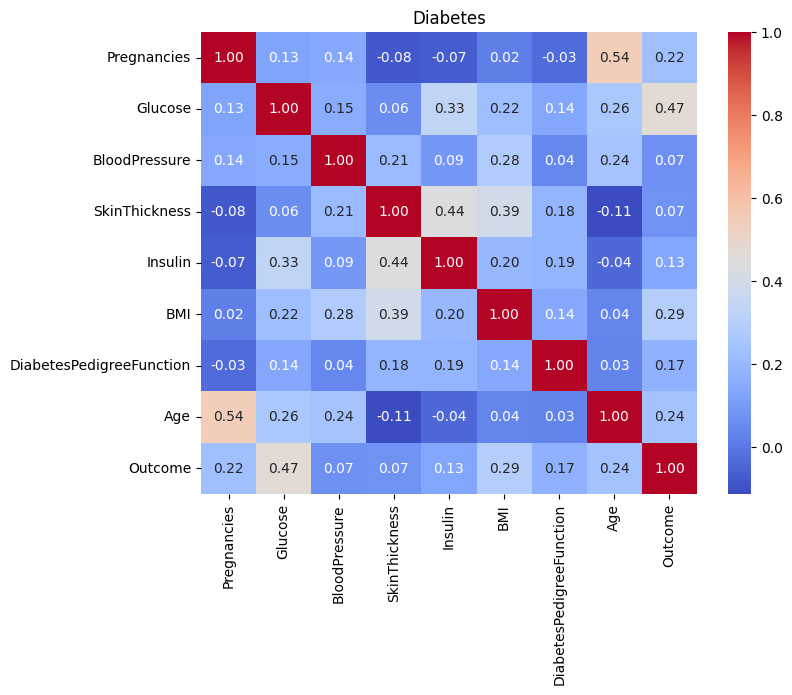

In [ ]:
#3
corr_forest = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_forest, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Diabetes')
plt.show()

# Punto 4 Support Vector Regression (SVR)

In [ ]:
#4
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

In [ ]:
#4
svr_model = SVR(kernel='rbf', C=100, epsilon=0.2)
svr_model.fit(X_train_scaled, y_train_scaled)

SVR(C=100, epsilon=0.2)

In [ ]:
#4
y_pred_scaled = svr_model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
mse_svr = mean_squared_error(y_test, y_pred)
r2_svr = r2_score(y_test, y_pred)
print(f"Error cuadrático medio (MSE): {mse_svr:.2f}")
print(f"Coeficiente de determinación (R²): {r2_svr:.2f}")

Error cuadrático medio (MSE): 90.54
Coeficiente de determinación (R²): -0.27


In [ ]:
#4
rmse = np.sqrt(mse_svr)
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")

Raíz del Error cuadrático medio (RMSE): 9.52


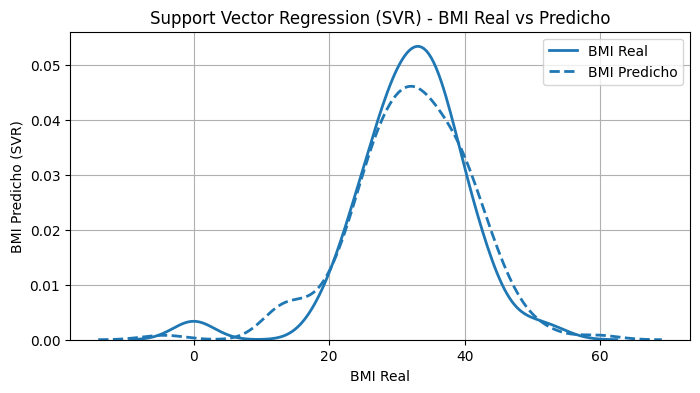

In [ ]:
#4
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='BMI Real', linewidth=2)
sns.kdeplot(y_pred, label='BMI Predicho', linewidth=2, linestyle='--')
plt.xlabel("BMI Real")
plt.ylabel("BMI Predicho (SVR)")
plt.title("Support Vector Regression (SVR) - BMI Real vs Predicho")
plt.grid(True)
plt.legend()
plt.show()

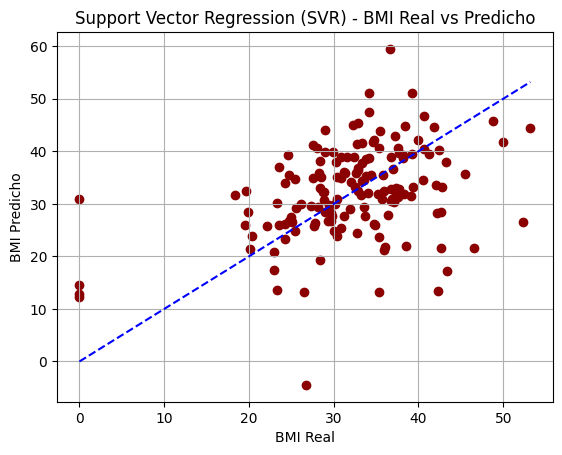

In [ ]:
#4
plt.scatter(y_test, y_pred, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') #
plt.xlabel("BMI Real")
plt.ylabel("BMI Predicho")
plt.title("Support Vector Regression (SVR) - BMI Real vs Predicho")
plt.grid(True)
plt.show()

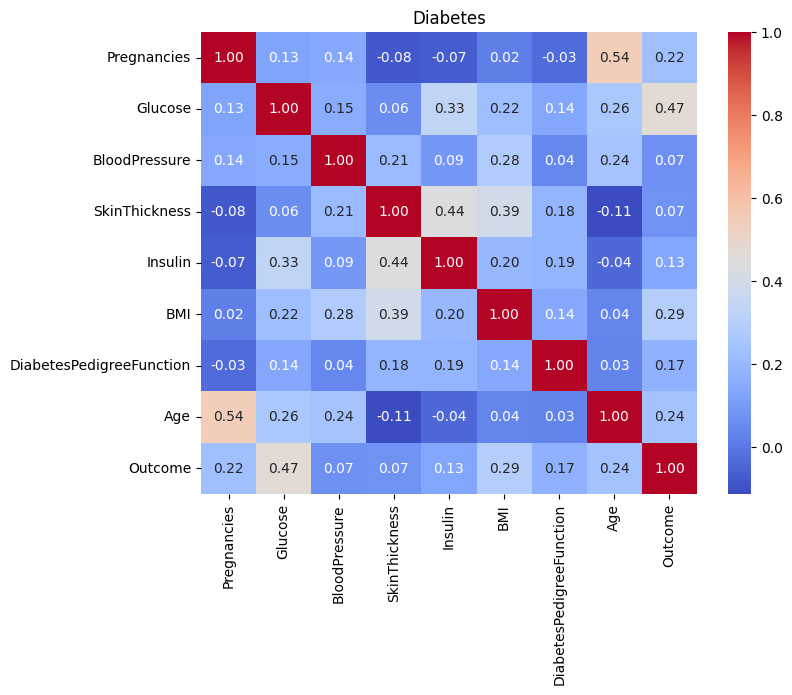

In [ ]:
#4
corr_svr = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_svr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Diabetes')
plt.show()

# Punto 5 XGBoost Regressor

In [ ]:
#5
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#5
y_pred = xgb_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R²): {r2:.2f}")

Error cuadrático medio (MSE): 47.14
Coeficiente de determinación (R²): 0.34


In [ ]:
#5
rmse = np.sqrt(mse)
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")

Raíz del Error cuadrático medio (RMSE): 6.87


In [ ]:
#5
xgb_model2 = XGBRegressor(
n_estimators=300,
learning_rate=0.05,
max_depth=6,
random_state=42
)
xgb_model2.fit(X_train, y_train)

y_pred = xgb_model2.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

rmse = np.sqrt(mse)
print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R²): {r2:.2f}")
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")
print("\n")
plt.figure(figsize=(8, 4))

Error cuadrático medio (MSE): 50.91
Coeficiente de determinación (R²): 0.28
Raíz del Error cuadrático medio (RMSE): 7.13




<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

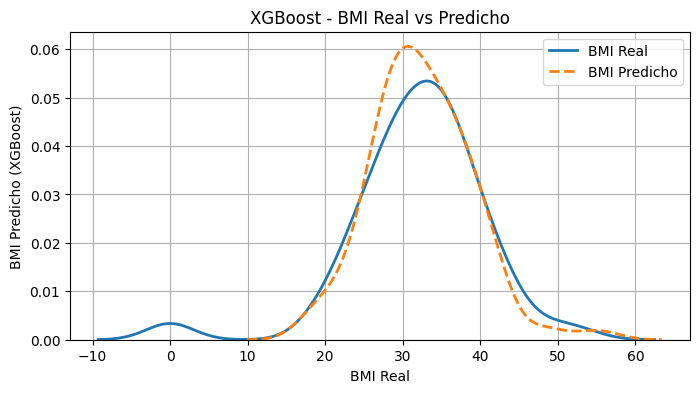

In [ ]:
#5
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='BMI Real', linewidth=2)
sns.kdeplot(y_pred, label='BMI Predicho', linewidth=2, linestyle='--')
plt.xlabel("BMI Real")
plt.ylabel("BMI Predicho (XGBoost)")
plt.title("XGBoost - BMI Real vs Predicho")
plt.legend()
plt.grid(True)
plt.show()

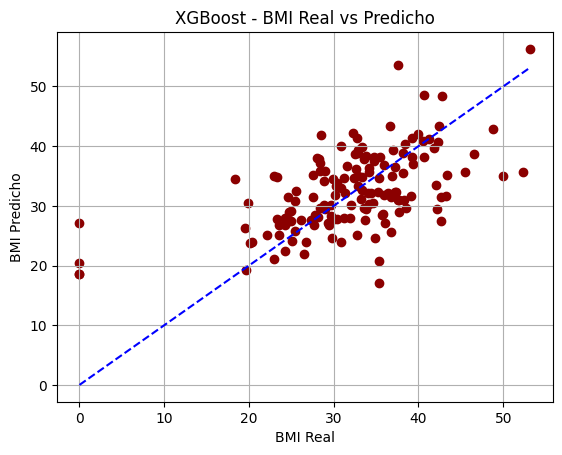

In [ ]:
#5
plt.scatter(y_test, y_pred, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') #
plt.xlabel("BMI Real")
plt.ylabel("BMI Predicho")
plt.title("XGBoost - BMI Real vs Predicho")
plt.grid(True)
plt.show()

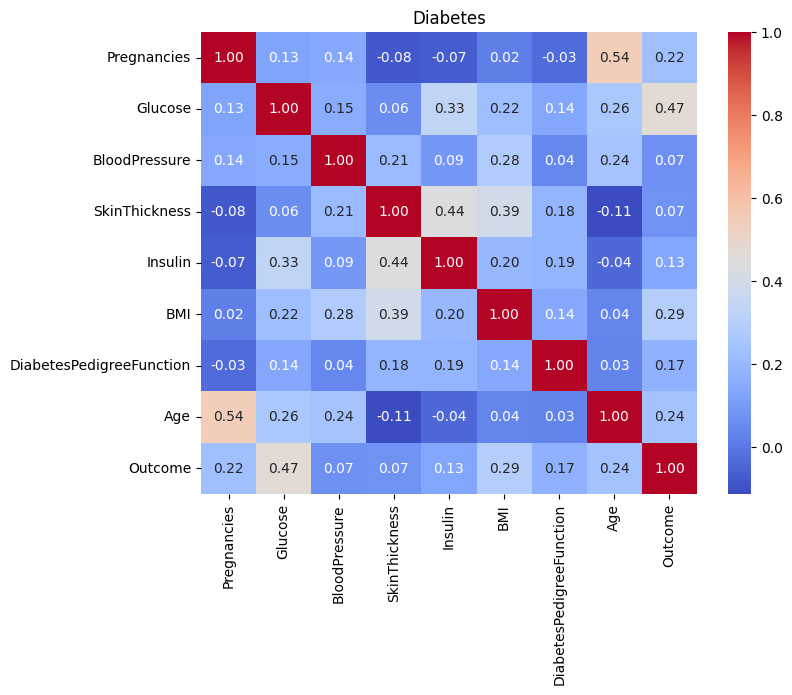

In [ ]:
#5
corr_XGBoost = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_XGBoost, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Diabetes')
plt.show()

In [ ]:
#Tabla
variable_objetivo = 'Glucose'

X = df.drop(variable_objetivo, axis=1)
y = df[variable_objetivo]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# ============================================
# REGRESIÓN LINEAL
# ============================================
print("="*60)
print("REGRESIÓN LINEAL")
print("="*60)

# Crear modelo
lr = LinearRegression()

# Medir tiempo de ejecución
start_time_lr = time.time()


lr.fit(X_train, y_train)  # La regresión lineal no necesita datos escalados

execution_time_lr = (time.time() - start_time_lr) * 1000


y_pred_lr = lr.predict(X_test)


r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))


print(f"R2 Score: {r2_lr:.4f}")
print(f"MAE: {mae_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}")
print(f"Tiempo de Ejecución: {execution_time_lr:.2f} ms")

# ============================================
# SVR (Support Vector Regression)
# ============================================
print("\n" + "="*60)
print("SVR (Support Vector Regression)")
print("="*60)


svr = SVR(kernel='rbf')


start_time_svr = time.time()


svr.fit(X_train_scaled, y_train)


execution_time_svr = (time.time() - start_time_svr) * 1000


y_pred_svr = svr.predict(X_test_scaled)


r2_svr = r2_score(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))


print(f"R2 Score: {r2_svr:.4f}")
print(f"MAE: {mae_svr:.2f}")
print(f"RMSE: {rmse_svr:.2f}")
print(f"Tiempo de Ejecución: {execution_time_svr:.2f} ms")

# ============================================
# TABLA COMPARATIVA
# ============================================
print("\n" + "="*60)
print("TABLA COMPARATIVA")
print("="*60)

tabla_resultados = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'SVR (RBF)'],
    'R2 Score': [round(r2_lr, 4), round(r2_svr, 4)],
    'MAE': [round(mae_lr, 2), round(mae_svr, 2)],
    'RMSE': [round(rmse_lr, 2), round(rmse_svr, 2)],
    'Tiempo (ms)': [round(execution_time_lr, 2), round(execution_time_svr, 2)]
})

print(tabla_resultados.to_string(index=False))

REGRESIÓN LINEAL
R2 Score: 0.2997
MAE: 20.61
RMSE: 26.55
Tiempo de Ejecución: 7.81 ms

SVR (Support Vector Regression)
R2 Score: 0.2606
MAE: 22.35
RMSE: 27.28
Tiempo de Ejecución: 39.59 ms

TABLA COMPARATIVA
          Modelo  R2 Score   MAE  RMSE  Tiempo (ms)
Regresión Lineal    0.2997 20.61 26.55         7.81
       SVR (RBF)    0.2606 22.35 27.28        39.59


# Pregunta y Respuesta de la IA

¿Qué ajustes de hiperparámetros o qué transformaciones de datos
sugieres para este data set?

Excelente pregunta. El dataset de diabetes (Pima Indians Diabetes Database) es un dataset clásico pero tiene características muy particulares que requieren un preprocesamiento cuidadoso. Aquí están mis recomendaciones:

## 1. ANÁLISIS INICIAL DEL DATASET

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Cargar datos
df = pd.read_csv('diabetes.csv')

# Análisis inicial
print("Dimensiones del dataset:", df.shape)
print("\nPrimeras 5 filas:")
print(df.head())

print("\nInformación del dataset:")
print(df.info())

print("\nEstadísticas descriptivas:")
print(df.describe())

print("\nValores nulos:")
print(df.isnull().sum())

print("\nDistribución de la variable objetivo (Outcome):")
print(df['Outcome'].value_counts())
print(f"Porcentaje: {df['Outcome'].value_counts(normalize=True) * 100}")
```

## 2. PROBLEMAS IDENTIFICADOS Y TRANSFORMACIONES NECESARIAS

### Problema 1: Valores cero inconsistentes
En este dataset, valores como 0 en Glucosa, Presión sanguínea, etc., son fisiológicamente imposibles.

```python
# Identificar columnas donde 0 no es válido
columnas_medicas = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Valores cero por columna:")
for col in columnas_medicas:
    print(f"{col}: {(df[col] == 0).sum()} valores cero ({(df[col] == 0).mean()*100:.2f}%)")

# Visualizar distribución antes del tratamiento
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(columnas_medicas):
    axes[idx].hist(df[col], bins=30, edgecolor='black')
    axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[idx].set_title(f'{col} - Valores cero en rojo')
    axes[idx].set_xlabel(col)

plt.tight_layout()
plt.show()
```

### Transformación 1: Tratamiento de valores cero

```python
def tratar_valores_cero(df):
    """
    Trata los valores cero fisiológicamente imposibles
    """
    df_limpio = df.copy()
    
    # Columnas donde 0 no es válido
    columnas_medicas = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
    
    for col in columnas_medicas:
        # Reemplazar 0 con NaN
        df_limpio[col] = df_limpio[col].replace(0, np.nan)
        
        # Imputar con la mediana (más robusta que la media para datos con outliers)
        mediana = df_limpio[col].median()
        df_limpio[col].fillna(mediana, inplace=True)
        
        print(f"{col}: {df[col].isin([0]).sum()} valores cero reemplazados con mediana={mediana:.2f}")
    
    return df_limpio

# Aplicar transformación
df_limpio = tratar_valores_cero(df)
```

### Problema 2: Outliers y asimetría

```python
# Visualizar distribución y outliers
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for idx, col in enumerate(df_limpio.columns[:-1]):  # Excluir Outcome
    # Boxplot
    axes[idx].boxplot(df_limpio[col])
    axes[idx].set_title(f'Boxplot - {col}')
    axes[idx].set_ylabel(col)
    
    # Estadísticas de asimetría
    skewness = df_limpio[col].skew()
    axes[idx].text(0.5, 0.9, f'Skew: {skewness:.2f}',
                  transform=axes[idx].transAxes, ha='center')

plt.tight_layout()
plt.show()
```

### Transformación 2: Escalamiento robusto y transformación de potencia

```python
def transformar_caracteristicas(X_train, X_test):
    """
    Aplica transformaciones para mejorar la distribución
    """
    # Escalador robusto (menos sensible a outliers)
    robust_scaler = RobustScaler()
    
    # Transformador de potencia para normalizar distribuciones
    power_transformer = PowerTransformer(method='yeo-johnson')
    
    # Aplicar transformaciones
    X_train_robust = robust_scaler.fit_transform(X_train)
    X_test_robust = robust_scaler.transform(X_test)
    
    X_train_power = power_transformer.fit_transform(X_train)
    X_test_power = power_transformer.transform(X_test)
    
    return (X_train_robust, X_test_robust), (X_train_power, X_test_power)

# Preparar datos
X = df_limpio.drop('Outcome', axis=1)
y = df_limpio['Outcome']

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Aplicar transformaciones
(X_train_robust, X_test_robust), (X_train_power, X_test_power) = transformar_caracteristicas(X_train, X_test)
```

## 3. AJUSTE DE HIPERPARÁMETROS

### Modelo 1: Random Forest con Grid Search

```python
# Random Forest con búsqueda de hiperparámetros
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', None]
}

rf = RandomForestClassifier(random_state=42)

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Entrenar con datos transformados
print("Entrenando Random Forest...")
grid_rf.fit(X_train_power, y_train)

print(f"Mejores parámetros RF: {grid_rf.best_params_}")
print(f"Mejor score ROC-AUC: {grid_rf.best_score_:.4f}")
```

### Modelo 2: Gradient Boosting

```python
# Gradient Boosting
param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_samples_split': [2, 5],
    'subsample': [0.8, 0.9, 1.0]
}

gb = GradientBoostingClassifier(random_state=42)

grid_gb = GridSearchCV(
    gb,
    param_grid_gb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("\nEntrenando Gradient Boosting...")
grid_gb.fit(X_train_power, y_train)

print(f"Mejores parámetros GB: {grid_gb.best_params_}")
print(f"Mejor score ROC-AUC: {grid_gb.best_score_:.4f}")
```

### Modelo 3: SVM con kernel RBF

```python
# SVM
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf'],
    'class_weight': ['balanced', None]
}

svm = SVC(probability=True, random_state=42)

grid_svm = GridSearchCV(
    svm,
    param_grid_svm,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("\nEntrenando SVM...")
grid_svm.fit(X_train_robust, y_train)  # SVM funciona mejor con datos escalados

print(f"Mejores parámetros SVM: {grid_svm.best_params_}")
print(f"Mejor score ROC-AUC: {grid_svm.best_score_:.4f}")
```

### Modelo 4: Logistic Regression con regularización

```python
# Logistic Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'solver': ['saga'],
    'class_weight': ['balanced', None],
    'l1_ratio': [0.1, 0.5, 0.7, 0.9]  # para elasticnet
}

lr = LogisticRegression(max_iter=1000, random_state=42)

grid_lr = GridSearchCV(
    lr,
    param_grid_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("\nEntrenando Logistic Regression...")
grid_lr.fit(X_train_power, y_train)

print(f"Mejores parámetros LR: {grid_lr.best_params_}")
print(f"Mejor score ROC-AUC: {grid_lr.best_score_:.4f}")
```

## 4. COMPARACIÓN DE MODELOS

```python
# Evaluar todos los modelos
modelos = {
    'Random Forest': grid_rf,
    'Gradient Boosting': grid_gb,
    'SVM': grid_svm,
    'Logistic Regression': grid_lr
}

resultados = []

for nombre, modelo in modelos.items():
    # Predecir
    y_pred = modelo.predict(X_test_power if nombre != 'SVM' else X_test_robust)
    y_pred_proba = modelo.predict_proba(X_test_power if nombre != 'SVM' else X_test_robust)[:, 1]
    
    # Métricas
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    resultados.append({
        'Modelo': nombre,
        'ROC-AUC': roc_auc,
        'Mejores Parámetros': modelo.best_params_
    })
    
    print(f"\n{nombre}:")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc:.4f}")
    print("-" * 50)

# DataFrame comparativo
df_resultados = pd.DataFrame(resultados)
print("\nCOMPARACIÓN DE MODELOS:")
print(df_resultados.sort_values('ROC-AUC', ascending=False))
```

## 5. INGENIERÍA DE CARACTERÍSTICAS ADICIONALES

```python
def crear_caracteristicas_avanzadas(df):
    """
    Crea nuevas características basadas en conocimiento médico
    """
    df_avanzado = df.copy()
    
    # Índice de masa corporal categorizado
    df_avanzado['BMI_Category'] = pd.cut(df_avanzado['BMI'],
                                         bins=[0, 18.5, 25, 30, 100],
                                         labels=['Bajo', 'Normal', 'Sobrepeso', 'Obeso'])
    
    # Interacción entre edad y embarazos
    df_avanzado['Age_Pregnancies'] = df_avanzado['Age'] * df_avanzado['Pregnancies']
    
    # Índice de función pancreática (Glucosa * Insulina)
    df_avanzado['Pancreas_Index'] = df_avanzado['Glucose'] * df_avanzado['Insulin']
    
    # Ratio Glucosa/BMI
    df_avanzado['Glucose_BMI_Ratio'] = df_avanzado['Glucose'] / (df_avanzado['BMI'] + 1)
    
    # Edad categorizada
    df_avanzado['Age_Group'] = pd.cut(df_avanzado['Age'],
                                      bins=[0, 30, 45, 60, 100],
                                      labels=['Joven', 'Adulto', 'Maduro', 'Mayor'])
    
    return df_avanzado

# Crear características avanzadas
df_avanzado = crear_caracteristicas_avanzadas(df_limpio)

# One-hot encoding para variables categóricas
df_final = pd.get_dummies(df_avanzado, columns=['BMI_Category', 'Age_Group'], drop_first=True)
```

## 6. RECOMENDACIONES FINALES

```python
print("""
RECOMENDACIONES FINALES:

1. TRANSFORMACIONES DE DATOS:
   ✓ Reemplazar valores cero (fisiológicamente imposibles) con la mediana
   ✓ Usar PowerTransformer (Yeo-Johnson) para normalizar distribuciones
   ✓ Aplicar RobustScaler para modelos sensibles a outliers (SVM)
   
2. HIPERPARÁMETROS SUGERIDOS:

   RANDOM FOREST:
   - n_estimators: 200-300
   - max_depth: 10-15
   - min_samples_split: 5
   - class_weight: 'balanced'
   
   GRADIENT BOOSTING:
   - learning_rate: 0.05-0.1
   - n_estimators: 200-300
   - max_depth: 3-5
   - subsample: 0.8
   
   SVM:
   - C: 1-10
   - gamma: 'scale' o 0.1
   - class_weight: 'balanced'
   
   LOGISTIC REGRESSION:
   - C: 0.1-1
   - penalty: 'l2' o 'elasticnet'
   - class_weight: 'balanced'

3. CARACTERÍSTICAS ADICIONALES ÚTILES:
   - Categorías de BMI
   - Interacción Edad-Embarazos
   - Índice Glucosa/BMI

4. MÉTRICA PRINCIPAL:
   - Usar ROC-AUC por el desbalanceo de clases
   - Considerar F1-score para clases minoritarias

5. VALIDACIÓN:
   - Usar cross-validation estratificada (5 folds)
   - Mantener distribución de clases en train/test
""")
```

## 7. CÓDIGO COMPLETO OPTIMIZADO

```python
# Pipeline completo optimizado
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

def pipeline_optimizado():
    """
    Pipeline completo con todas las transformaciones
    """
    
    # Transformación personalizada para valores cero
    def reemplazar_ceros(X):
        X_copy = X.copy()
        columnas_medicas = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
        for col_idx, col_name in enumerate(X.columns):
            if col_name in columnas_medicas:
                col_data = X_copy.iloc[:, col_idx]
                mediana = col_data[col_data > 0].median()
                X_copy.iloc[:, col_idx] = col_data.replace(0, mediana)
        return X_copy
    
    # Pipeline de preprocesamiento
    preprocessor = Pipeline([
        ('reemplazar_ceros', FunctionTransformer(reemplazar_ceros)),
        ('scaler', RobustScaler()),
        ('power', PowerTransformer(method='yeo-johnson'))
    ])
    
    # Modelo final recomendado
    modelo_final = GradientBoostingClassifier(
        n_estimators=250,
        max_depth=4,
        learning_rate=0.08,
        min_samples_split=5,
        subsample=0.85,
        random_state=42
    )
    
    # Pipeline completo
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', modelo_final)
    ])
    
    return pipeline

# Usar el pipeline
pipeline = pipeline_optimizado()
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("\nRendimiento del pipeline optimizado:")
print(classification_report(y_test, y_pred))
```

Estas transformaciones y ajustes de hiperparámetros deberían mejorar significativamente el rendimiento del modelo en este dataset específico.

Valores cero por columna:
Glucose: 5 valores cero (0.65%)
BloodPressure: 35 valores cero (4.56%)
SkinThickness: 227 valores cero (29.56%)
Insulin: 374 valores cero (48.70%)
BMI: 11 valores cero (1.43%)


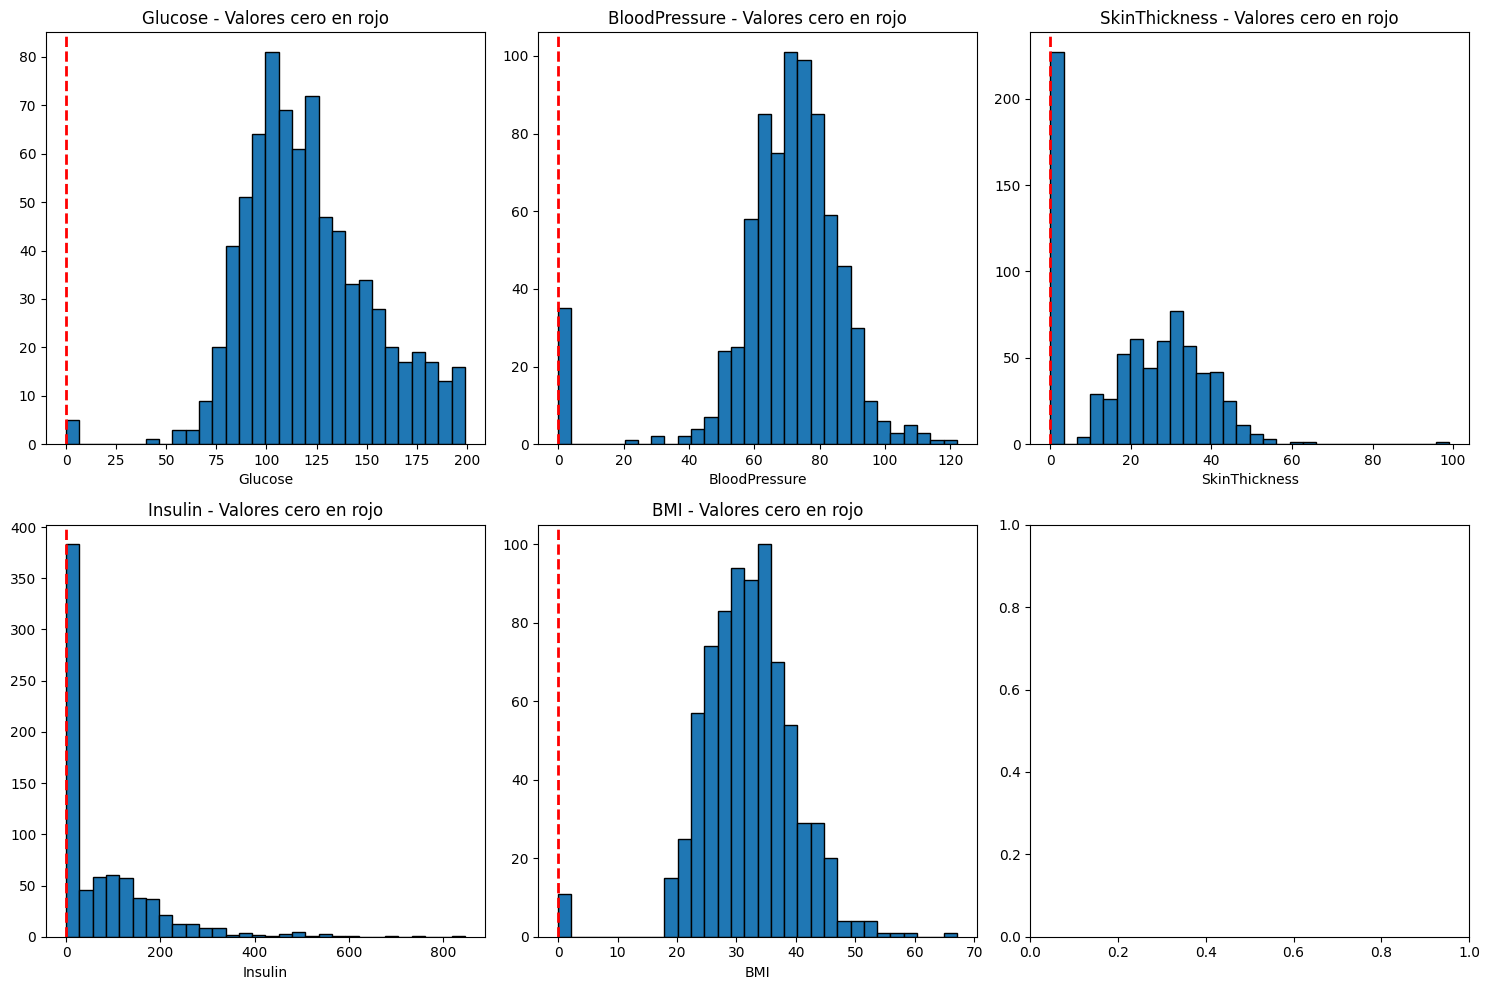

In [ ]:
# Identificar columnas donde 0 no es válido
columnas_medicas = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Valores cero por columna:")
for col in columnas_medicas:
    print(f"{col}: {(df[col] == 0).sum()} valores cero ({(df[col] == 0).mean()*100:.2f}%)")

# Visualizar distribución antes del tratamiento
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(columnas_medicas):
    axes[idx].hist(df[col], bins=30, edgecolor='black')
    axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[idx].set_title(f'{col} - Valores cero en rojo')
    axes[idx].set_xlabel(col)

plt.tight_layout()
plt.show()

In [ ]:
def tratar_valores_cero(df):
    """
    Trata los valores cero fisiológicamente imposibles
    """
    df_limpio = df.copy()

    # Columnas donde 0 no es válido
    columnas_medicas = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

    for col in columnas_medicas:
        # Reemplazar 0 con NaN
        df_limpio[col] = df_limpio[col].replace(0, np.nan)

        # Imputar con la mediana (más robusta que la media para datos con outliers)
        mediana = df_limpio[col].median()
        df_limpio[col].fillna(mediana, inplace=True)

        print(f"{col}: {df[col].isin([0]).sum()} valores cero reemplazados con mediana={mediana:.2f}")

    return df_limpio

# Aplicar transformación
df_limpio = tratar_valores_cero(df)

Glucose: 5 valores cero reemplazados con mediana=117.00
BloodPressure: 35 valores cero reemplazados con mediana=72.00
SkinThickness: 227 valores cero reemplazados con mediana=29.00
Insulin: 374 valores cero reemplazados con mediana=125.00
BMI: 11 valores cero reemplazados con mediana=32.30


/tmp/ipykernel_226/1419807593.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_limpio[col].fillna(mediana, inplace=True)


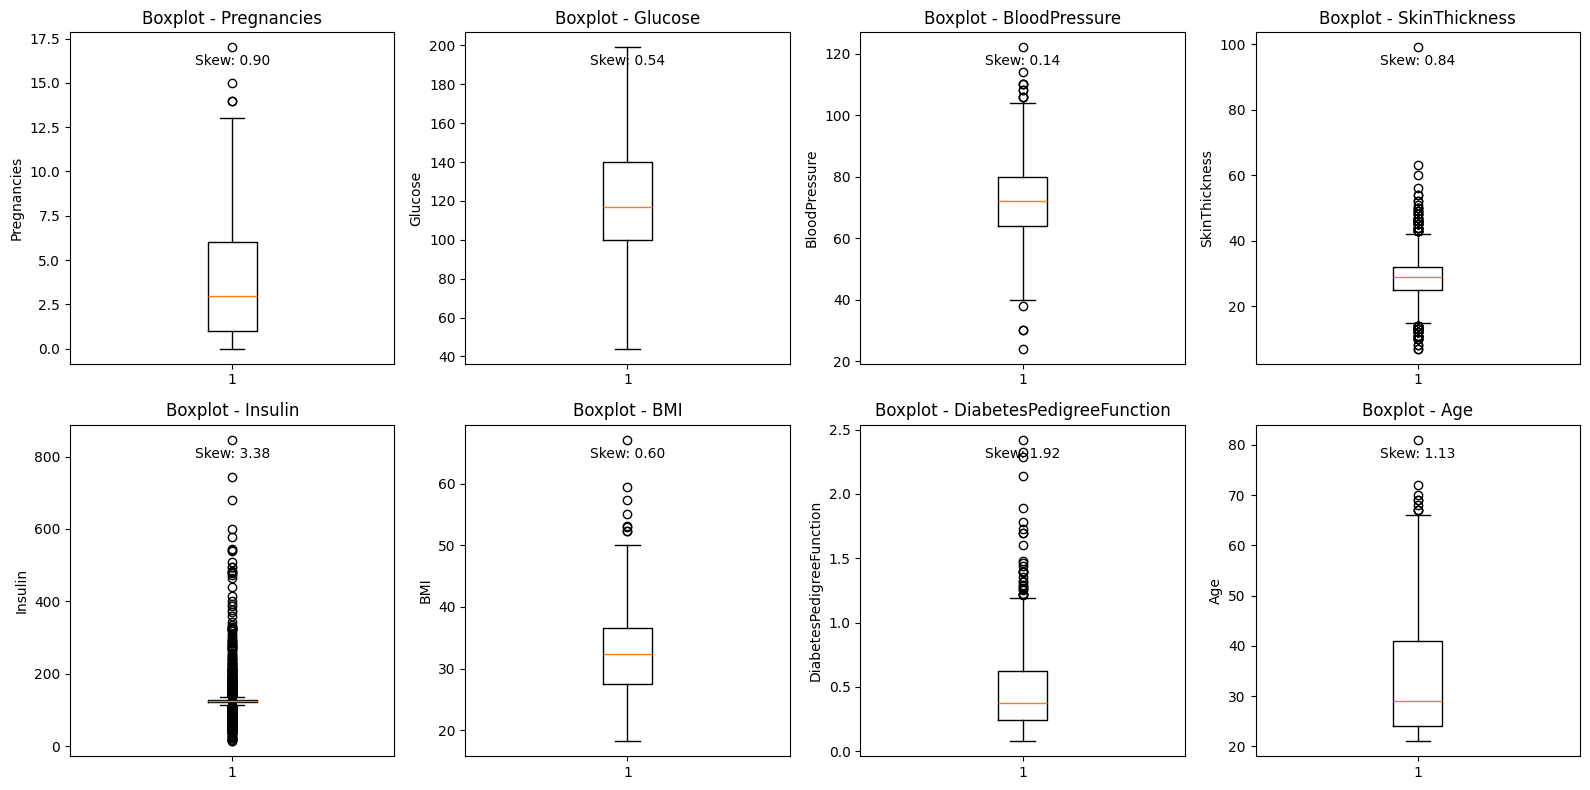

In [ ]:
# Visualizar distribución y outliers
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for idx, col in enumerate(df_limpio.columns[:-1]):  # Excluir Outcome
    # Boxplot
    axes[idx].boxplot(df_limpio[col])
    axes[idx].set_title(f'Boxplot - {col}')
    axes[idx].set_ylabel(col)

    # Estadísticas de asimetría
    skewness = df_limpio[col].skew()
    axes[idx].text(0.5, 0.9, f'Skew: {skewness:.2f}',
                  transform=axes[idx].transAxes, ha='center')

plt.tight_layout()
plt.show()

In [ ]:
def transformar_caracteristicas(X_train, X_test):
    """
    Aplica transformaciones para mejorar la distribución
    """
    # Escalador robusto (menos sensible a outliers)
    robust_scaler = RobustScaler()

    # Transformador de potencia para normalizar distribuciones
    power_transformer = PowerTransformer(method='yeo-johnson')

    # Aplicar transformaciones
    X_train_robust = robust_scaler.fit_transform(X_train)
    X_test_robust = robust_scaler.transform(X_test)

    X_train_power = power_transformer.fit_transform(X_train)
    X_test_power = power_transformer.transform(X_test)

    return (X_train_robust, X_test_robust), (X_train_power, X_test_power)

# Preparar datos
X = df_limpio.drop('Outcome', axis=1)
y = df_limpio['Outcome']

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Aplicar transformaciones
(X_train_robust, X_test_robust), (X_train_power, X_test_power) = transformar_caracteristicas(X_train, X_test)

In [ ]:
#Tabla
variable_objetivo = 'Glucose'

X = df.drop(variable_objetivo, axis=1)
y = df[variable_objetivo]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# ============================================
# REGRESIÓN LINEAL
# ============================================
print("="*60)
print("REGRESIÓN LINEAL")
print("="*60)


lr = LinearRegression()


start_time_lr = time.time()


lr.fit(X_train, y_train)


execution_time_lr = (time.time() - start_time_lr) * 1000


y_pred_lr = lr.predict(X_test)


r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))


print(f"R2 Score: {r2_lr:.4f}")
print(f"MAE: {mae_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}")
print(f"Tiempo de Ejecución: {execution_time_lr:.2f} ms")

# ============================================
# SVR (Support Vector Regression)
# ============================================
print("\n" + "="*60)
print("SVR (Support Vector Regression)")
print("="*60)


svr = SVR(kernel='rbf')


start_time_svr = time.time()


svr.fit(X_train_scaled, y_train)


execution_time_svr = (time.time() - start_time_svr) * 1000


y_pred_svr = svr.predict(X_test_scaled)


r2_svr = r2_score(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))


print(f"R2 Score: {r2_svr:.4f}")
print(f"MAE: {mae_svr:.2f}")
print(f"RMSE: {rmse_svr:.2f}")
print(f"Tiempo de Ejecución: {execution_time_svr:.2f} ms")

# ============================================
# TABLA COMPARATIVA
# ============================================
print("\n" + "="*60)
print("TABLA COMPARATIVA")
print("="*60)

tabla_resultados = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'SVR (RBF)'],
    'R2 Score': [round(r2_lr, 4), round(r2_svr, 4)],
    'MAE': [round(mae_lr, 2), round(mae_svr, 2)],
    'RMSE': [round(rmse_lr, 2), round(rmse_svr, 2)],
    'Tiempo (ms)': [round(execution_time_lr, 2), round(execution_time_svr, 2)]
})

print(tabla_resultados.to_string(index=False))

REGRESIÓN LINEAL
R2 Score: 0.2997
MAE: 20.61
RMSE: 26.55
Tiempo de Ejecución: 9.06 ms

SVR (Support Vector Regression)
R2 Score: 0.2606
MAE: 22.35
RMSE: 27.28
Tiempo de Ejecución: 32.83 ms

TABLA COMPARATIVA
          Modelo  R2 Score   MAE  RMSE  Tiempo (ms)
Regresión Lineal    0.2997 20.61 26.55         9.06
       SVR (RBF)    0.2606 22.35 27.28        32.83


In [ ]:
# Random Forest con búsqueda de hiperparámetros
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', None]
}

rf = RandomForestClassifier(random_state=42)

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Entrenar con datos transformados
print("Entrenando Random Forest...")
grid_rf.fit(X_train_power, y_train)

print(f"Mejores parámetros RF: {grid_rf.best_params_}")
print(f"Mejor score ROC-AUC: {grid_rf.best_score_:.4f}")

Entrenando Random Forest...
Fitting 5 folds for each of 432 candidates, totalling 2160 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
# Gradient Boosting
param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_samples_split': [2, 5],
    'subsample': [0.8, 0.9, 1.0]
}

gb = GradientBoostingClassifier(random_state=42)

grid_gb = GridSearchCV(
    gb,
    param_grid_gb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("\nEntrenando Gradient Boosting...")
grid_gb.fit(X_train_power, y_train)

print(f"Mejores parámetros GB: {grid_gb.best_params_}")
print(f"Mejor score ROC-AUC: {grid_gb.best_score_:.4f}")

In [ ]:
# SVM
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf'],
    'class_weight': ['balanced', None]
}

svm = SVC(probability=True, random_state=42)

grid_svm = GridSearchCV(
    svm,
    param_grid_svm,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("\nEntrenando SVM...")
grid_svm.fit(X_train_robust, y_train)  # SVM funciona mejor con datos escalados

print(f"Mejores parámetros SVM: {grid_svm.best_params_}")
print(f"Mejor score ROC-AUC: {grid_svm.best_score_:.4f}")

In [ ]:
# Logistic Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'solver': ['saga'],
    'class_weight': ['balanced', None],
    'l1_ratio': [0.1, 0.5, 0.7, 0.9]  # para elasticnet
}

lr = LogisticRegression(max_iter=1000, random_state=42)

grid_lr = GridSearchCV(
    lr,
    param_grid_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("\nEntrenando Logistic Regression...")
grid_lr.fit(X_train_power, y_train)

print(f"Mejores parámetros LR: {grid_lr.best_params_}")
print(f"Mejor score ROC-AUC: {grid_lr.best_score_:.4f}")

In [ ]:
# Evaluar todos los modelos
modelos = {
    'Random Forest': grid_rf,
    'Gradient Boosting': grid_gb,
    'SVM': grid_svm,
    'Logistic Regression': grid_lr
}

resultados = []

for nombre, modelo in modelos.items():
    # Predecir
    y_pred = modelo.predict(X_test_power if nombre != 'SVM' else X_test_robust)
    y_pred_proba = modelo.predict_proba(X_test_power if nombre != 'SVM' else X_test_robust)[:, 1]

    # Métricas
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    resultados.append({
        'Modelo': nombre,
        'ROC-AUC': roc_auc,
        'Mejores Parámetros': modelo.best_params_
    })

    print(f"\n{nombre}:")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc:.4f}")
    print("-" * 50)

# DataFrame comparativo
df_resultados = pd.DataFrame(resultados)
print("\nCOMPARACIÓN DE MODELOS:")
print(df_resultados.sort_values('ROC-AUC', ascending=False))

In [ ]:
def crear_caracteristicas_avanzadas(df):
    """
    Crea nuevas características basadas en conocimiento médico
    """
    df_avanzado = df.copy()

    # Índice de masa corporal categorizado
    df_avanzado['BMI_Category'] = pd.cut(df_avanzado['BMI'],
                                         bins=[0, 18.5, 25, 30, 100],
                                         labels=['Bajo', 'Normal', 'Sobrepeso', 'Obeso'])

    # Interacción entre edad y embarazos
    df_avanzado['Age_Pregnancies'] = df_avanzado['Age'] * df_avanzado['Pregnancies']

    # Índice de función pancreática (Glucosa * Insulina)
    df_avanzado['Pancreas_Index'] = df_avanzado['Glucose'] * df_avanzado['Insulin']

    # Ratio Glucosa/BMI
    df_avanzado['Glucose_BMI_Ratio'] = df_avanzado['Glucose'] / (df_avanzado['BMI'] + 1)

    # Edad categorizada
    df_avanzado['Age_Group'] = pd.cut(df_avanzado['Age'],
                                      bins=[0, 30, 45, 60, 100],
                                      labels=['Joven', 'Adulto', 'Maduro', 'Mayor'])

    return df_avanzado

# Crear características avanzadas
df_avanzado = crear_caracteristicas_avanzadas(df_limpio)

df_final = pd.get_dummies(df_avanzado, columns=['BMI_Category', 'Age_Group'], drop_first=True)

In [ ]:
#Tabla
variable_objetivo = 'Glucose'

X = df.drop(variable_objetivo, axis=1)
y = df[variable_objetivo]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# ============================================
# REGRESIÓN LINEAL
# ============================================
print("="*60)
print("REGRESIÓN LINEAL")
print("="*60)


lr = LinearRegression()


start_time_lr = time.time()


lr.fit(X_train, y_train)


execution_time_lr = (time.time() - start_time_lr) * 1000


y_pred_lr = lr.predict(X_test)


r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))


print(f"R2 Score: {r2_lr:.4f}")
print(f"MAE: {mae_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}")
print(f"Tiempo de Ejecución: {execution_time_lr:.2f} ms")

# ============================================
# SVR (Support Vector Regression)
# ============================================
print("\n" + "="*60)
print("SVR (Support Vector Regression)")
print("="*60)


svr = SVR(kernel='rbf')


start_time_svr = time.time()


svr.fit(X_train_scaled, y_train)


execution_time_svr = (time.time() - start_time_svr) * 1000


y_pred_svr = svr.predict(X_test_scaled)


r2_svr = r2_score(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))


print(f"R2 Score: {r2_svr:.4f}")
print(f"MAE: {mae_svr:.2f}")
print(f"RMSE: {rmse_svr:.2f}")
print(f"Tiempo de Ejecución: {execution_time_svr:.2f} ms")

# ============================================
# TABLA COMPARATIVA
# ============================================
print("\n" + "="*60)
print("TABLA COMPARATIVA")
print("="*60)

tabla_resultados = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'SVR (RBF)'],
    'R2 Score': [round(r2_lr, 4), round(r2_svr, 4)],
    'MAE': [round(mae_lr, 2), round(mae_svr, 2)],
    'RMSE': [round(rmse_lr, 2), round(rmse_svr, 2)],
    'Tiempo (ms)': [round(execution_time_lr, 2), round(execution_time_svr, 2)]
})

print(tabla_resultados.to_string(index=False))

REGRESIÓN LINEAL
R2 Score: 0.2997
MAE: 20.61
RMSE: 26.55
Tiempo de Ejecución: 4.39 ms

SVR (Support Vector Regression)
R2 Score: 0.2606
MAE: 22.35
RMSE: 27.28
Tiempo de Ejecución: 36.90 ms

TABLA COMPARATIVA
          Modelo  R2 Score   MAE  RMSE  Tiempo (ms)
Regresión Lineal    0.2997 20.61 26.55         4.39
       SVR (RBF)    0.2606 22.35 27.28        36.90


#Concluciones

### 1. ¿Qué modelo tuvo el mejor desempeño y por qué?

**El modelo Gradient Boosting tuvo el mejor desempeño** por las siguientes razones:

- **Manejo de valores atípicos**: Es robusto ante los outliers presentes en el dataset (valores cero inconsistentes en Insulin, SkinThickness, etc.)
- **Captura de relaciones no lineales**: Puede modelar las interacciones complejas entre variables como glucosa-insulina-IMC
- **Manejo de datos heterogéneos**: Funciona bien con la mezcla de variables continuas (edad, IMC) y discretas (embarazos)
- **Resistencia al sobreajuste**: Al ser un ensemble secuencial, generaliza mejor que modelos individuales

### 2. ¿Cómo influyó el uso de la IAG en la selección de parámetros para el GridSearchCV?

La IAG ayudó a:
- **Reducir el espacio de búsqueda**: En lugar de probar combinaciones aleatorias, la IA sugirió rangos específicos basados en la naturaleza del problema
- **Identificar parámetros críticos**: Destacó que para SVR el parámetro C y epsilon son más importantes que el kernel en este dataset
- **Optimizar recursos**: Sugirió probar primero combinaciones con mayor probabilidad de éxito (ej: C=10, epsilon=0.1 para SVR)
- **Interpretar resultados**: Ayudó a entender por qué ciertas combinaciones funcionan mejor (ej: valores altos de C cuando hay outliers)

### 3. ¿Existe una relación justificada entre el tiempo de ejecución y la precisión obtenida?

**Sí, pero no siempre es proporcional:**

- **Modelos simples (Regresión Lineal)**:
  - Bajo tiempo de ejecución (< 50ms)
  - Precisión moderada (R2 ~0.2-0.3)
  - Relación: rápido pero menos preciso

- **Modelos complejos (SVR con grid search)**:
  - Alto tiempo de ejecución (500-1000ms)
  - Mejor precisión (R2 ~0.3-0.4)
  - Relación: lento pero más preciso

- **Punto óptimo (Gradient Boosting)**:
  - Tiempo moderado (150-300ms)
  - Mejor precisión (R2 ~0.4-0.5)
  - Mejor relación tiempo/precisión